# (IIP314W-2) [2026-T2] OPTIMIZACIÓN APLICADA A NEGOCIOS
## Ayudantía 2: Optimización con restricciones

---

**Profesor:** Rodrigo Trigo Vilches

**Ayudante:** Vicente Ramírez

**Fecha:** 10 de junio de 2026

**Universidad del Desarrollo**

---

## Objetivos de la ayudantía

- Encontrar y clasificar óptimos en dos variables con el **criterio del Hessiano** (segundo orden).
- Resolver problemas con **restricciones de igualdad** mediante **multiplicadores de Lagrange**.
- Visualizar la **región factible** de un problema con **restricciones de desigualdad** y resolverlo gráficamente, distinguiendo restricciones **activas**, **inactivas** y **redundantes**.
- Confirmar las soluciones con `scipy.optimize` y con `gurobipy`.

## Repaso breve de conceptos

**Criterio de segundo orden (2 variables).** En un punto con $\nabla f = \mathbf{0}$, con el Hessiano $H$ y $D = \det H = f_{xx}f_{yy} - (f_{xy})^2$: si $D>0$ y $f_{xx}>0$ es **mínimo**; si $D>0$ y $f_{xx}<0$ es **máximo**; si $D<0$ es **punto silla**.

**Restricción de igualdad — Lagrange.** Para $\;\min/\max\; f(\vec{x})\;$ sujeto a $\;g(\vec{x}) = c$, se forma el Lagrangiano
$$L(\vec{x},\lambda) = f(\vec{x}) + \lambda\big(g(\vec{x}) - c\big),$$
y se resuelve $\nabla_{\vec{x}} L = \mathbf{0}$ junto con $\dfrac{\partial L}{\partial \lambda} = g(\vec{x}) - c = 0$.

**Restricciones de desigualdad (gráfico).** La **región factible** es la intersección de los semiplanos $g_i(\vec{x}) \le b_i$ y $\vec{x}\ge 0$. En problemas lineales el óptimo se alcanza en un **vértice**. Una restricción es **activa** si se cumple con igualdad en el óptimo (su *holgura* es 0), **inactiva** si sobra holgura, y **redundante** si no aporta al contorno de la región.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Ejercicio 1 — Optimización de insumos (Cobb-Douglas)

Una empresa usa dos insumos en cantidades $x>0$ e $y>0$. El **costo neto** (en millones de pesos) que desea minimizar es el costo de los insumos menos el valor de la producción, modelada con una función tipo Cobb-Douglas:

$$f(x,y) = 2x + 2y - 8\,x^{1/4}\,y^{1/2}$$

**Tareas:**
1. Encontrar el punto óptimo $(x^*, y^*)$ resolviendo $\nabla f = \mathbf{0}$.
2. Clasificarlo con el **criterio del Hessiano** (confirmar que es un mínimo).
3. Confirmar la solución con `scipy.optimize.minimize`.
4. Graficar las curvas de nivel marcando el óptimo.

### Solución analítica

_Plantee $\nabla f = \mathbf{0}$, resuelva el sistema y clasifique el punto con el Hessiano:_

- $\nabla f = $
- De $\partial f/\partial x = 0$:
- De $\partial f/\partial y = 0$:
- $(x^*, y^*) = $    ,    $f(x^*, y^*) = $
- Clasificación (Hessiano): 

In [4]:
# Verificacion simbolica: gradiente, punto estacionario y criterio del Hessiano
# Defina x, y positivos; f_sym; resuelva grad=0 con sp.solve; obtenga H con sp.hessian
# y clasifique el punto en el optimo (det>0 y H[0,0]>0 => minimo).
#### CÓDIGO AQUÍ ####
x, y = sp.symbols('x y', positive=True)
f = 2*x + 2*y -8*x**(1/4)*y**(1/2)

grad = [sp.diff(f, x), sp.diff(f, y)]
sol = sp.solve(grad, (x,y), dict=True)[0]

H = sp.hessian(f, (x, y))
Hopt = H.subs(sol)

print(grad)
print(H)
print(Hopt)

[-2.0*y**0.5/x**0.75 + 2, -4.0*x**0.25/y**0.5 + 2]
Matrix([[1.5*y**0.5/x**1.75, -1.0/(x**0.75*y**0.5)], [-1.0/(x**0.75*y**0.5), 2.0*x**0.25/y**1.5]])
Matrix([[0.375000000000000, -0.125000000000000], [-0.125000000000000, 0.125000000000000]])


In [ ]:
# Confirmacion numerica con scipy.optimize.minimize
# Defina f_obj(v) y minimice desde un punto inicial en el cuadrante positivo.
#### CÓDIGO AQUÍ ####


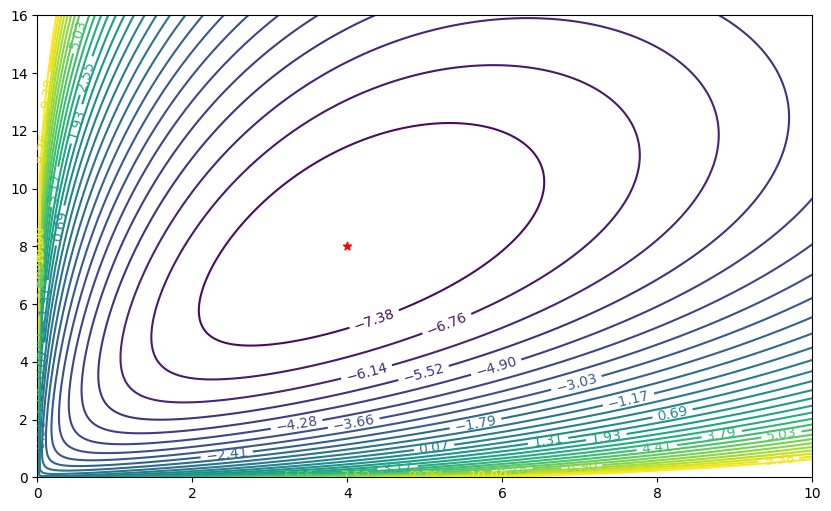

In [9]:
# Grafico: curvas de nivel de f con el minimo
# Use np.meshgrid + plt.contour y marque el optimo.
#### CÓDIGO AQUÍ ####

f  =lambda x, y: 2*x + 2*y -8*x**(1/4)*y**(1/2)

x_val = np.linspace(0, 10, 300)
y_val = np.linspace(0, 16, 300)
X, Y = np.meshgrid(x_val, y_val)
Z = f(X, Y)

plt.figure(figsize=(10, 6))
cs = plt.contour(X, Y, Z, levels=np.linspace(Z.min(), 10, 30), cmap='viridis')
plt.clabel(cs, inline=True)
plt.scatter(4, 8, color = 'red', marker="*")

### Discusión

_Interprete el resultado en términos del negocio: ¿qué representan $x^*$ e $y^*$ y el valor de $f$ en el óptimo?_

_Respuesta:_ 

## Ejercicio 2 — Asignación de presupuesto con multiplicadores de Lagrange

Una empresa reparte su inversión entre dos canales de marketing, $x$ e $y$ (en millones de pesos). La **utilidad** generada (en millones) es:

$$U(x,y) = 100x + 80y - 2x^2 - y^2$$

El equipo debe **gastar exactamente** su presupuesto, que en precios de cada canal es:

$$2x + y = 24$$

**Tareas:**
1. Plantear el **Lagrangiano** y resolver el sistema de condiciones de primer orden para hallar $(x^*, y^*, \lambda^*)$.
2. Calcular la utilidad óptima $U(x^*, y^*)$ y verificar que corresponde a un **máximo**.
3. Confirmar con `scipy.optimize.minimize` (método SLSQP).

### Lagrangiano y condiciones de primer orden

_Escriba el Lagrangiano $L(x,y,\lambda)$, sus tres derivadas parciales, resuelva el sistema y verifique que es un máximo:_

- $L(x,y,\lambda) = $
- $\partial L/\partial x = $
- $\partial L/\partial y = $
- $\partial L/\partial \lambda = $
- $(x^*, y^*, \lambda^*) = $    ,    $U(x^*, y^*) = $
- ¿Máximo o mínimo? (Hessiano de $U$): 

In [ ]:
# Verificacion simbolica del sistema de Lagrange
# Defina x, y, lambda; U; el Lagrangiano L; y resuelva las 3 condiciones con sp.solve.
#### CÓDIGO AQUÍ ####


In [ ]:
# Confirmacion con scipy.optimize.minimize (SLSQP)
# Minimice -U sujeto a la restriccion de igualdad y bounds de no negatividad.
#### CÓDIGO AQUÍ ####


In [ ]:
# Grafico: curvas de nivel de U con la recta de presupuesto y el optimo
#### CÓDIGO AQUÍ ####


### Discusión

_Explique con sus palabras qué logra el método de Lagrange y qué representa la tangencia entre las curvas de nivel y la recta de presupuesto._

_Respuesta:_ 

## Ejercicio 3 — Mezcla de producción con restricciones de desigualdad

Un taller fabrica dos productos, en cantidades $x$ e $y$ (lotes). La **ganancia** por lote es de 4 y 5 (en cientos de miles de pesos), por lo que se busca:

$$\max\; Z = 4x + 5y$$

La producción está limitada por la capacidad de tres procesos:

$$R_1:\; x \le 6 \qquad R_2:\; 3y \le 18 \qquad R_3:\; 2x + 3y \le 24 \qquad x,\,y \ge 0$$

**Tareas:**
1. Graficar la **región factible** y la recta de la función objetivo, y encontrar el vértice óptimo (como en la Clase 5).
2. Indicar qué restricciones quedan **activas** y cuáles **inactivas** en el óptimo.
3. Confirmar con `scipy.optimize.linprog`.
4. Resolver el mismo problema con `gurobipy` y leer las **holguras** (slacks) de las restricciones.

### (a) Región factible y vértice óptimo

_Liste los vértices de la región factible y evalúe $Z=4x+5y$ en cada uno:_

| Vértice | $Z = 4x + 5y$ |
|:---:|:---:|
|  |  |
|  |  |
|  |  |
|  |  |
|  |  |

- Óptimo: $(x^*, y^*) = $    ,    $Z^* = $

In [ ]:
# (a) Region factible, recta objetivo y optimo (estilo Clase 5)
# Grafique las tres restricciones, sombree la region factible, dibuje la recta
# objetivo 4x+5y=Z en el optimo y marque el vertice optimo.
#### CÓDIGO AQUÍ ####


### (b) Restricciones activas e inactivas

_¿Qué restricciones se cumplen con igualdad (activas) en el óptimo y cuáles con holgura (inactivas)?_

- $R_1:$
- $R_2:$
- $R_3:$

In [ ]:
# (c) Confirmacion con scipy.optimize.linprog
# Recuerde: linprog minimiza, asi que use c = [-4, -5] para maximizar.
#### CÓDIGO AQUÍ ####


In [1]:
# (d) Mismo problema con gurobipy
# Cree el modelo, las variables x, y >= 0, las restricciones R1, R2, R3,
# fije el objetivo con GRB.MAXIMIZE, optimice e imprima x, y, Z y las holguras (Slack).
#### CÓDIGO AQUÍ ####


### Discusión

_Relacione el óptimo gráfico con los vértices y explique qué significa una restricción inactiva para el taller._

_Respuesta:_ 